# NFL Week 1 Analysis — Upset Analysis

This notebook evaluates whether Week 1 is unusually chaotic using three definitions of an upset.

In [2]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import confint_proportions_2indep, proportions_ztest
from scipy.stats import ttest_ind, mannwhitneyu
import matplotlib.pyplot as plt

games = pd.read_parquet("../data/games.parquet")
team_results = pd.read_parquet("../data/team_results.parquet")

print("games:", games.shape)
print("team_results:", team_results.shape)


games: (4927, 15)
team_results: (9854, 4)


## 1. Record-based upset definition

For each game, compare the teams using the number of wins they earn **after that game**. For Week 1 this means Weeks 2–18, avoiding circularity from using the Week 1 result itself.

In [13]:
# Calculate each team's wins AFTER each game.
team_results_future = team_results.copy()

future_wins = (
    team_results_future
    .merge(
        team_results_future[["season", "team", "week"]],
        on=["season", "team"],
        suffixes=("", "_game")
    )
)

future_wins = future_wins[
    future_wins["week"] > future_wins["week_game"]
]

future_wins = (
    future_wins
    .groupby(["season", "team", "week_game"])["wins"]
    .sum()
    .reset_index(name="future_wins")
)

games = games.merge(
    future_wins.rename(
        columns={
            "team": "team_home",
            "week_game": "week",
            "future_wins": "home_future_wins"
        }
    ),
    on=["season", "team_home", "week"],
    how="left",
    validate="many_to_one"
)

games = games.merge(
    future_wins.rename(
        columns={
            "team": "team_away",
            "week_game": "week",
            "future_wins": "away_future_wins"
        }
    ),
    on=["season", "team_away", "week"],
    how="left",
    validate="many_to_one"
)

games["future_win_difference"] = (
    games["home_future_wins"] -
    games["away_future_wins"]
).abs()

games["record_upset_future"] = (
    (
        (games["home_future_wins"] < games["away_future_wins"]) &
        (games["score_home"] > games["score_away"])
    )
    |
    (
        (games["away_future_wins"] < games["home_future_wins"]) &
        (games["score_away"] > games["score_home"])
    )
)

print("Missing home future wins:", games["home_future_wins"].isna().sum())
print("Missing away future wins:", games["away_future_wins"].isna().sum())


Missing home future wins: 304
Missing away future wins: 304


In [14]:
week1 = games[games["week"] == 1]

print("Week 1 record upsets:", week1["record_upset_future"].sum())
print(
    "Week 1 comparable games:",
    (week1["future_win_difference"] > 0).sum()
)
print(
    "Week 1 conditional rate:",
    week1.loc[
        week1["future_win_difference"] > 0,
        "record_upset_future"
    ].mean()
)


Week 1 record upsets: 98
Week 1 comparable games: 279
Week 1 conditional rate: 0.35125448028673834


## 2. Betting-market upset test

In [15]:
week1 = games["week"] == 1
later = games["week"] >= 2

count_a = [
    games.loc[week1, "betting_upset"].sum(),
    games.loc[later, "betting_upset"].sum()
]
nobs_a = [
    week1.sum(),
    later.sum()
]

z_a, p_a = proportions_ztest(count_a, nobs_a)

ci_a_low, ci_a_high = confint_proportions_2indep(
    count1=count_a[0],
    nobs1=nobs_a[0],
    count2=count_a[1],
    nobs2=nobs_a[1],
    method="wald"
)

print("Week 1 betting upsets:", count_a[0], "/", nobs_a[0])
print("Weeks 2–18 betting upsets:", count_a[1], "/", nobs_a[1])
print("Difference:", count_a[0] / nobs_a[0] - count_a[1] / nobs_a[1])
print("95% CI:", (ci_a_low, ci_a_high))
print("z-statistic:", z_a)
print("p-value:", p_a)


Week 1 betting upsets: 107 / 303
Weeks 2–18 betting upsets: 1530 / 4624
Difference: 0.022252960590176674
95% CI: (np.float64(-0.033244739638917234), np.float64(0.07775066081927058))
z-statistic: 0.7966856931845391
p-value: 0.42563359499463416


## 3. Subsequent-record upset test

In [16]:
week1_games = games[games["week"] == 1]
later_games = games[games["week"] >= 2]

week1_comparable = week1_games["future_win_difference"] > 0
later_comparable = later_games["future_win_difference"] > 0

week1_upsets = week1_games.loc[
    week1_comparable,
    "record_upset_future"
].sum()
week1_total = week1_comparable.sum()

later_upsets = later_games.loc[
    later_comparable,
    "record_upset_future"
].sum()
later_total = later_comparable.sum()

week1_rate = week1_upsets / week1_total
later_rate = later_upsets / later_total

z_b, p_b = proportions_ztest(
    [week1_upsets, later_upsets],
    [week1_total, later_total]
)

difference_b = week1_rate - later_rate

se_b = np.sqrt(
    (week1_rate * (1 - week1_rate) / week1_total)
    +
    (later_rate * (1 - later_rate) / later_total)
)

ci_b_lower = difference_b - 1.96 * se_b
ci_b_upper = difference_b + 1.96 * se_b

print("Week 1:")
print("  Upsets:", week1_upsets)
print("  Comparable games:", week1_total)
print("  Rate:", week1_rate)

print("\nWeeks 2–18:")
print("  Upsets:", later_upsets)
print("  Comparable games:", later_total)
print("  Rate:", later_rate)

print("\nDifference:", difference_b)
print("95% CI:", (ci_b_lower, ci_b_upper))
print("z-statistic:", z_b)
print("p-value:", p_b)


Week 1:
  Upsets: 98
  Comparable games: 279
  Rate: 0.35125448028673834

Weeks 2–18:
  Upsets: 1267
  Comparable games: 3496
  Rate: 0.3624141876430206

Difference: -0.011159707356282245
95% CI: (np.float64(-0.0693968133156421), np.float64(0.047077398603077615))
z-statistic: -0.3733569591820538
p-value: 0.708882788822164


## 4. Spread-based upset magnitude

In [17]:
print("Missing spreads:", games["spread_favorite"].isna().sum())

games["spread_deviation"] = (
    games["favorite_margin"] + games["spread_favorite"]
)

games["spread_upset_magnitude"] = (
    -games["spread_deviation"]
)

games.loc[
    ~games["betting_upset"],
    "spread_upset_magnitude"
] = 0

games.loc[
    games["favorite_team"] == "PICK",
    "spread_upset_magnitude"
] = 0


Missing spreads: 0


In [18]:
week1_magnitude = games.loc[
    (games["week"] == 1) & games["betting_upset"],
    "spread_upset_magnitude"
]

later_magnitude = games.loc[
    (games["week"] >= 2) & games["betting_upset"],
    "spread_upset_magnitude"
]

t_stat, t_p = ttest_ind(
    week1_magnitude,
    later_magnitude,
    equal_var=False
)

u_stat, u_p = mannwhitneyu(
    week1_magnitude,
    later_magnitude,
    alternative="two-sided"
)

print("Week 1:")
print(week1_magnitude.describe())

print("\nWeeks 2–18:")
print(later_magnitude.describe())

print("\nWelch's t-test p-value:", t_p)
print("Mann–Whitney U p-value:", u_p)


Week 1:
count    107.000000
mean      14.158879
std        8.774856
min        2.000000
25%        8.000000
50%       11.500000
75%       18.500000
max       39.000000
Name: spread_upset_magnitude, dtype: float64

Weeks 2–18:
count    1530.000000
mean       13.605229
std         7.777021
min         2.000000
25%         8.000000
50%        11.500000
75%        18.000000
max        52.000000
Name: spread_upset_magnitude, dtype: float64

Welch's t-test p-value: 0.5263726208859018
Mann–Whitney U p-value: 0.7701712511429457


## 5. Large Week 1 upsets

In [19]:
week1 = games[games["week"] == 1].copy()

week1["big_betting_upset"] = (
    week1["betting_upset"] &
    (week1["spread_favorite"] <= -5)
)

week1["big_record_upset"] = (
    week1["record_upset_future"] &
    (week1["future_win_difference"] >= 4)
)

print("Week 1 games:", len(week1))
print("Betting upsets:", week1["betting_upset"].sum())
print("Record upsets:", week1["record_upset_future"].sum())
print(
    "5+ point underdog games:",
    (week1["spread_favorite"] <= -5).sum()
)
print(
    "5+ point underdog wins:",
    week1["big_betting_upset"].sum()
)
print(
    "4+ eventual-win-gap upsets:",
    week1["big_record_upset"].sum()
)

print("\n5+ point underdog upset rate:",
      week1["big_betting_upset"].sum()
      / (week1["spread_favorite"] <= -5).sum())

print("4+ eventual-win-gap rate:",
      week1["big_record_upset"].mean())


Week 1 games: 303
Betting upsets: 107
Record upsets: 98
5+ point underdog games: 120
5+ point underdog wins: 28
4+ eventual-win-gap upsets: 35

5+ point underdog upset rate: 0.23333333333333334
4+ eventual-win-gap rate: 0.11551155115511551


## 6. Visualizations

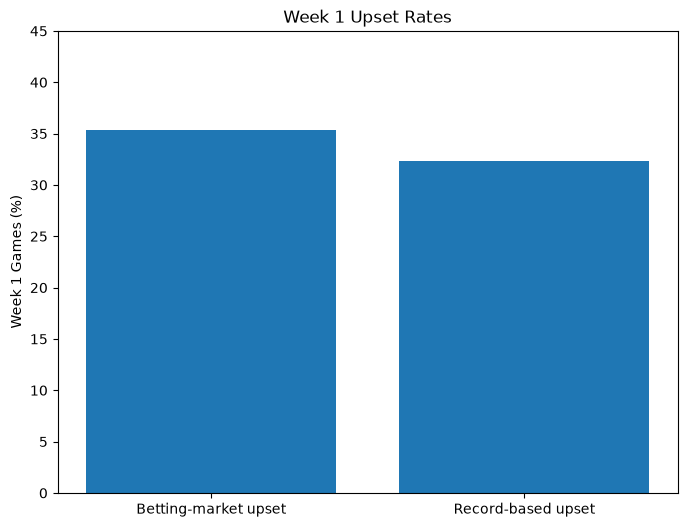

In [20]:
# Main Q1 visualization: overall Week 1 upset rates.
upset_rates = pd.DataFrame({
    "Definition": [
        "Betting-market upset",
        "Record-based upset"
    ],
    "Rate": [
        week1["betting_upset"].mean() * 100,
        week1["record_upset_future"].mean() * 100
    ]
})

plt.figure(figsize=(8, 6))
plt.bar(
    upset_rates["Definition"],
    upset_rates["Rate"]
)
plt.ylabel("Week 1 Games (%)")
plt.title("Week 1 Upset Rates")
plt.ylim(0, 45)
plt.show()


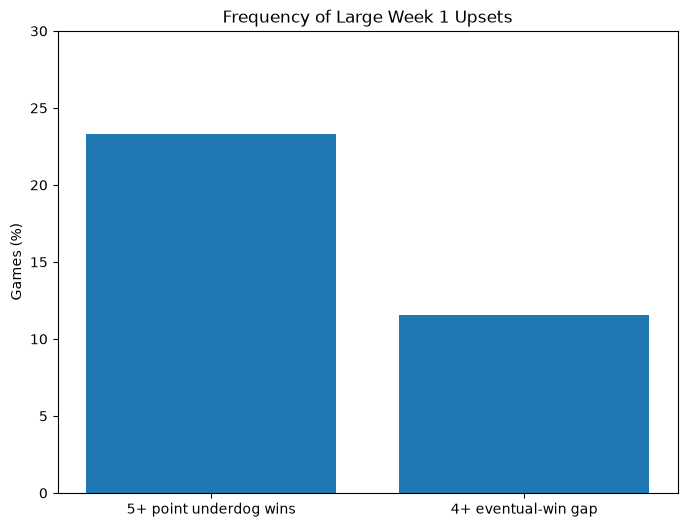

In [21]:
# Large-upset visualization.
big_upset_rates = pd.DataFrame({
    "Definition": [
        "5+ point underdog wins",
        "4+ eventual-win gap"
    ],
    "Rate": [
        (
            week1["big_betting_upset"].sum()
            / (week1["spread_favorite"] <= -5).sum()
        ) * 100,
        week1["big_record_upset"].mean() * 100
    ]
})

plt.figure(figsize=(8, 6))
plt.bar(
    big_upset_rates["Definition"],
    big_upset_rates["Rate"]
)
plt.ylabel("Games (%)")
plt.title("Frequency of Large Week 1 Upsets")
plt.ylim(0, 30)
plt.show()


## Q1 takeaway

The betting-market and subsequent-record definitions both place Week 1 upset frequency around 35%. The revised record-based comparison finds no statistically significant difference between Week 1 and Weeks 2–18.